<a href="https://colab.research.google.com/github/Ayaz2836/Billing-system/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import library and derive dataset from kaggle

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
import os
import pandas as pd
path_df=os.path.join(path,"creditcard.csv")
df=pd.read_csv(path_df)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.duplicated().sum()

np.int64(1081)

#checking missing value whether present or not

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


<Axes: >

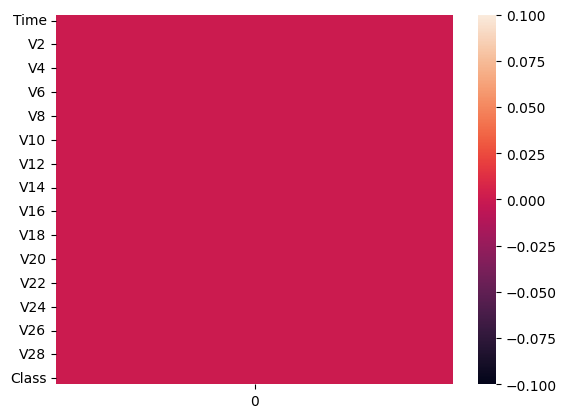

In [ ]:
sns.heatmap(df.isnull().sum().to_frame())

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


#checking datatype

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

#classification of data into two parts
binary classification

1. legit
2. fraud



In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
legit=df[df.Class==0]
fraud=df[df.Class==1]


In [ ]:
legit

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [ ]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [ ]:
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


#checking dataset is balence or imbalence

In [ ]:
legit.shape,fraud.shape

((284315, 31), (492, 31))

#handling imbalance datset

In [ ]:
legit_sample=legit.sample(n=492)

In [ ]:
legit_sample

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
54739,46594.0,-0.352781,0.784804,-0.030918,-1.213527,2.459426,3.365564,0.115579,0.937155,-0.521070,...,-0.283099,-0.903428,-0.061688,0.983523,-0.036537,0.086466,0.268068,0.114003,0.89,0
158100,110928.0,0.160762,1.360423,-0.635800,0.880905,1.555988,-0.458386,1.286477,-0.286602,0.109548,...,0.174518,0.955085,-0.043125,0.668952,-0.792196,-0.606030,0.498553,0.327427,6.99,0
91127,63324.0,0.793579,-1.317752,0.867805,0.651266,-1.318633,0.799929,-0.905026,0.363607,-0.474704,...,-0.210726,-0.538808,-0.112249,-0.367210,0.095446,-0.383375,0.056661,0.061715,223.00,0
113201,72979.0,1.001118,-0.409053,0.110967,0.079585,-0.638120,-0.973332,0.275431,-0.245005,0.192317,...,0.037311,0.024136,-0.084425,0.735420,0.287581,1.453731,-0.126390,0.010851,125.65,0
269498,163671.0,-0.570322,0.718804,2.145648,-0.351663,-0.210460,-0.362478,0.488704,0.002745,0.692829,...,-0.233526,-0.427928,-0.289494,-0.120820,0.256563,-0.660802,0.181187,-0.084405,1.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133593,80454.0,-0.743675,-0.031827,0.600965,-1.580226,2.173611,3.830664,-0.291907,1.020366,-1.244900,...,-0.426540,-0.829088,-0.307998,0.962352,0.777719,-0.381915,0.075762,0.065622,19.99,0
251630,155431.0,-1.331325,-5.918657,-3.446897,1.421914,-1.423687,0.419438,2.329126,-0.603381,0.901598,...,0.858485,-1.336504,-1.410725,0.140464,-0.594095,-0.268687,-0.365518,0.253691,1783.78,0
284293,172309.0,0.344370,1.102244,1.068651,4.657317,-0.329900,1.902216,-1.740517,-2.232675,-1.193324,...,-1.061565,0.994068,-0.046954,0.439506,0.227830,0.568449,0.192322,0.313544,15.13,0
269750,163755.0,-2.153779,-0.826809,1.860189,0.416165,2.303033,-1.360460,-0.471615,-0.342325,0.151636,...,-0.685654,-1.209942,-0.743198,1.155038,0.026461,-0.616174,0.119304,-0.324057,12.99,0


In [ ]:
fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [ ]:
new_dataset=pd.concat([legit_sample,fraud],axis=0)

In [ ]:
new_dataset

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
54739,46594.0,-0.352781,0.784804,-0.030918,-1.213527,2.459426,3.365564,0.115579,0.937155,-0.521070,...,-0.283099,-0.903428,-0.061688,0.983523,-0.036537,0.086466,0.268068,0.114003,0.89,0
158100,110928.0,0.160762,1.360423,-0.635800,0.880905,1.555988,-0.458386,1.286477,-0.286602,0.109548,...,0.174518,0.955085,-0.043125,0.668952,-0.792196,-0.606030,0.498553,0.327427,6.99,0
91127,63324.0,0.793579,-1.317752,0.867805,0.651266,-1.318633,0.799929,-0.905026,0.363607,-0.474704,...,-0.210726,-0.538808,-0.112249,-0.367210,0.095446,-0.383375,0.056661,0.061715,223.00,0
113201,72979.0,1.001118,-0.409053,0.110967,0.079585,-0.638120,-0.973332,0.275431,-0.245005,0.192317,...,0.037311,0.024136,-0.084425,0.735420,0.287581,1.453731,-0.126390,0.010851,125.65,0
269498,163671.0,-0.570322,0.718804,2.145648,-0.351663,-0.210460,-0.362478,0.488704,0.002745,0.692829,...,-0.233526,-0.427928,-0.289494,-0.120820,0.256563,-0.660802,0.181187,-0.084405,1.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


#splitting data into two parts

In [ ]:
y=new_dataset['Class']
x=new_dataset.drop(columns='Class',axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=43)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((787, 30), (197, 30), (787,), (197,))

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr=LogisticRegression()

In [ ]:
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred=lr.predict(x_test)
dataset=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
dataset

,Actual,Predicted
108268,0,0
204064,1,1
95597,1,1
243393,1,1
6331,1,1
...,...,...
234632,1,1
14701,0,0
83873,0,0
192287,0,0


In [ ]:
new_dataset.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

#accuracy test

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

In [ ]:
accuracy_score(y_test,lr.predict(x_test))

0.9593908629441624

In [ ]:
confusion_matrix(y_test,lr.predict(x_test))

array([[ 87,   3],
       [  5, 102]])

In [ ]:
classification_report(y_test,lr.predict(x_test))

'              precision    recall  f1-score   support\n\n           0       0.95      0.97      0.96        90\n           1       0.97      0.95      0.96       107\n\n    accuracy                           0.96       197\n   macro avg       0.96      0.96      0.96       197\nweighted avg       0.96      0.96      0.96       197\n'

In [ ]:
recall_score(y_test,lr.predict(x_test))

0.9532710280373832

In [ ]:
precision_score(y_test,lr.predict(x_test))

0.9714285714285714

In [ ]:
f1_score(y_test,lr.predict(x_test))

0.9622641509433962

In [ ]:
new_dataset

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
54739,46594.0,-0.352781,0.784804,-0.030918,-1.213527,2.459426,3.365564,0.115579,0.937155,-0.521070,...,-0.283099,-0.903428,-0.061688,0.983523,-0.036537,0.086466,0.268068,0.114003,0.89,0
158100,110928.0,0.160762,1.360423,-0.635800,0.880905,1.555988,-0.458386,1.286477,-0.286602,0.109548,...,0.174518,0.955085,-0.043125,0.668952,-0.792196,-0.606030,0.498553,0.327427,6.99,0
91127,63324.0,0.793579,-1.317752,0.867805,0.651266,-1.318633,0.799929,-0.905026,0.363607,-0.474704,...,-0.210726,-0.538808,-0.112249,-0.367210,0.095446,-0.383375,0.056661,0.061715,223.00,0
113201,72979.0,1.001118,-0.409053,0.110967,0.079585,-0.638120,-0.973332,0.275431,-0.245005,0.192317,...,0.037311,0.024136,-0.084425,0.735420,0.287581,1.453731,-0.126390,0.010851,125.65,0
269498,163671.0,-0.570322,0.718804,2.145648,-0.351663,-0.210460,-0.362478,0.488704,0.002745,0.692829,...,-0.233526,-0.427928,-0.289494,-0.120820,0.256563,-0.660802,0.181187,-0.084405,1.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


#Data viualization

In [ ]:
legit=new_dataset[new_dataset.Class==0]
fraud=new_dataset[new_dataset.Class==1]

<Axes: xlabel='Class', ylabel='count'>

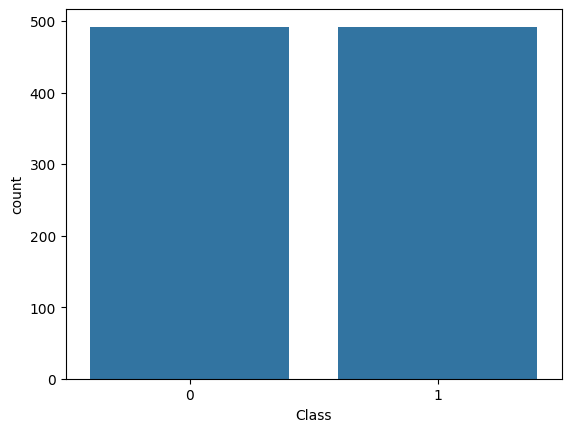

In [ ]:
sns.countplot(x='Class',data=new_dataset)

<Axes: xlabel='Class', ylabel='Amount'>

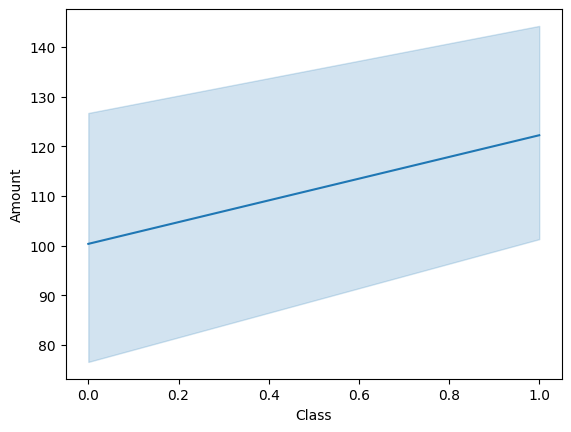

In [ ]:
sns.lineplot(x='Class',y='Amount',data=new_dataset)

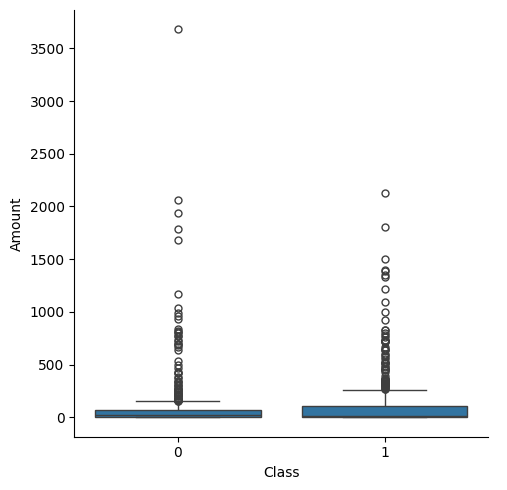

In [ ]:
sns.catplot(x='Class',y='Amount',data=new_dataset,kind='box')
#

<Axes: xlabel='Class', ylabel='Amount'>

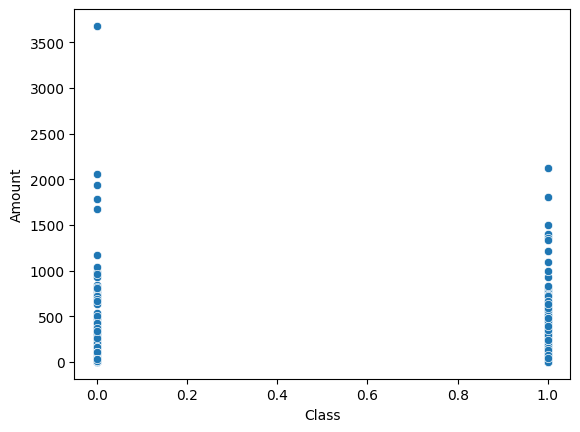

In [ ]:
sns.scatterplot(x='Class',y='Amount',data=new_dataset)


<Axes: xlabel='Class', ylabel='Amount'>

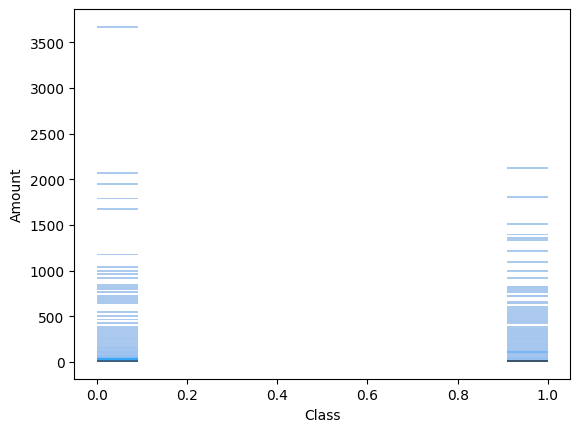

In [ ]:
sns.histplot(x='Class',y='Amount',data=new_dataset)


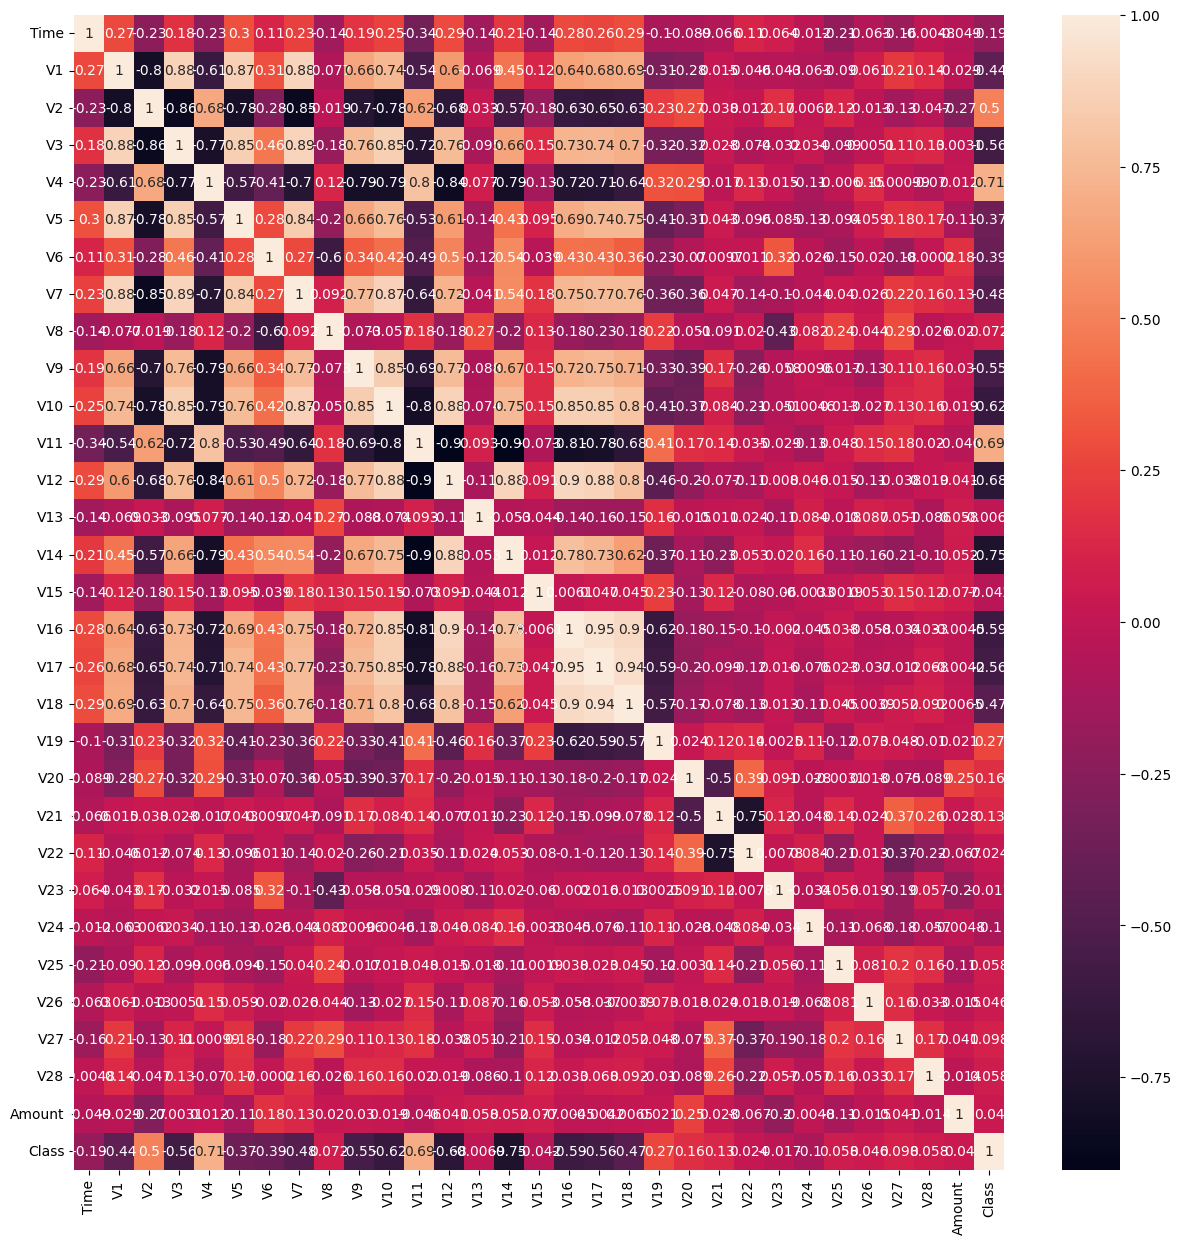

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(new_dataset.corr(),annot=True)
plt.show()